In [2]:
from matplotlib import pyplot as plt
import numpy as np

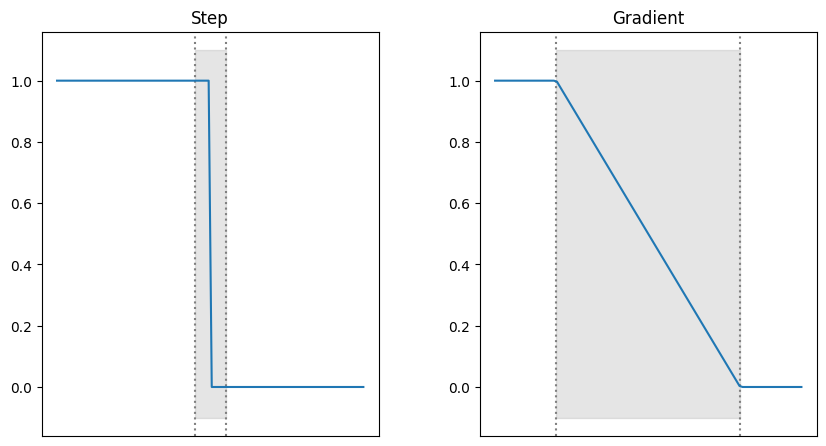

In [20]:
# Generate a step data set, a gradient line dataset, a concave curve, and a convex curve
# From the same starting to end value
x = np.linspace(0, 10, 100)
y1 = np.piecewise(x, [x < 5, x >= 5], [1, 0])

# Make a graph that is 1 until x=2, then linearly decreases to 0 at x=8, then stays at 0
y2 = np.piecewise(
    x,
    [x <= 2, np.logical_and(x > 2, x < 8), x >= 8],
    [lambda x: 1, lambda x: 1 - (x - 2) / (8 - 2), lambda x: 0]
)

# y2 = 1 - x / max(x)

# Plot the datasets in a 2x2 grid with one empty subplot, and make each subplot square
fig, axs = plt.subplots(1, 2, figsize=(10, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
# Set square aspect ratio for each subplot, scaling y so 0-1 matches 0-10 in x
# Hide the X axis values for all subplots
for ax in axs.flat:
    ax.set_aspect(10, adjustable='box')
    ax.set_xticks([])


# For the first plot, draw some vertical dotted lines either side of the step
# and shade lightly between them to represent where the boundary is
axs[0].axvline(x=4.5, color='gray', linestyle='dotted')
axs[0].axvline(x=5.5, color='gray', linestyle='dotted')
axs[0].fill_betweenx(y=[-0.1, 1.1], x1=4.5, x2=5.5, color='gray', alpha=0.2)

axs[0].plot(x, y1, label='Step')
axs[0].set_title('Step')

# For the second plot, draw vertical bars at x=2 and x=8 to represent the start and end of the gradient
# and shade lightly between them to represent the area of change
axs[1].axvline(x=2, color='gray', linestyle='dotted')
axs[1].axvline(x=8, color='gray', linestyle='dotted')
axs[1].fill_betweenx(y=[-0.1, 1.1], x1=2, x2=8, color='gray', alpha=0.2)

axs[1].plot(x, y2, label='Gradient')
axs[1].set_title('Gradient')

plt.show()

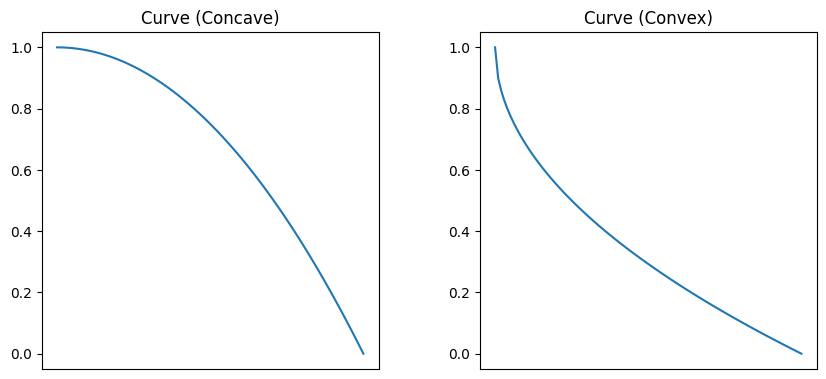

In [15]:
y3 = 1 - (x / max(x))**2
# Concave curve with greatest rate of change at start, least at end, from (0,0) to (10,1)
y4 = 1 - np.sqrt(x / max(x))
# Plot the datasets in a 2x2 grid with one empty subplot, and make each subplot square
fig, axs = plt.subplots(1, 2, figsize=(10, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Set square aspect ratio for each subplot, scaling y so 0-1 matches 0-10 in x
for ax in axs.flat:
    ax.set_aspect(10, adjustable='box')
    ax.set_xticks([])

axs[0].plot(x, y3, label='Curve')
axs[0].set_title('Curve (Concave)')

axs[1].plot(x, y4, label='Curve')
axs[1].set_title('Curve (Convex)')
plt.show()

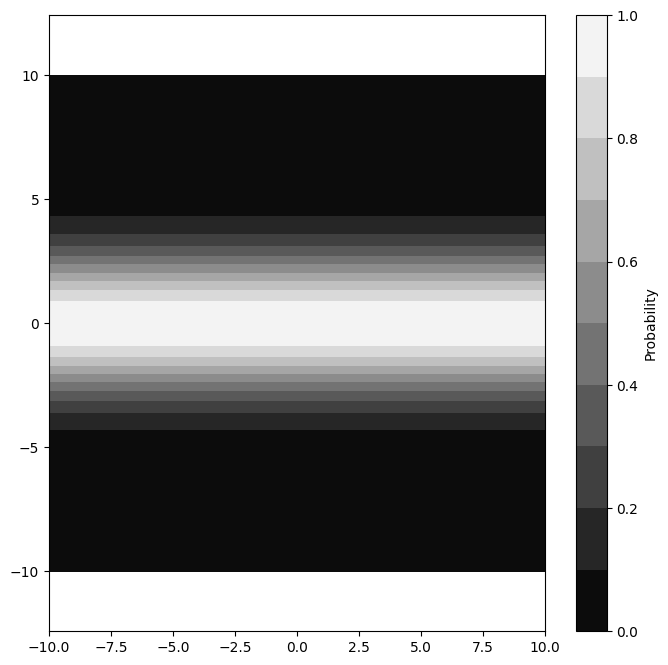

In [25]:
# Formulae - a horizontal line, at 0.
# With intensity 1 following the line, then dropping off smoothly to 0 above and below, over a distance of 8 units.
# The line spans about 20 units.
x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)
Z = np.exp(-((Y)**2) / (2 * (2**2)))
Z = Z / np.max(Z)  # Normalize to 0-1
plt.figure(figsize=(8, 8))
plt.contourf(X, Y, Z, levels=10, cmap='grey')
plt.colorbar(label='Probability')
# plt.title('Intensity around a Horizontal Line')
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
plt.axis('equal')
plt.show()


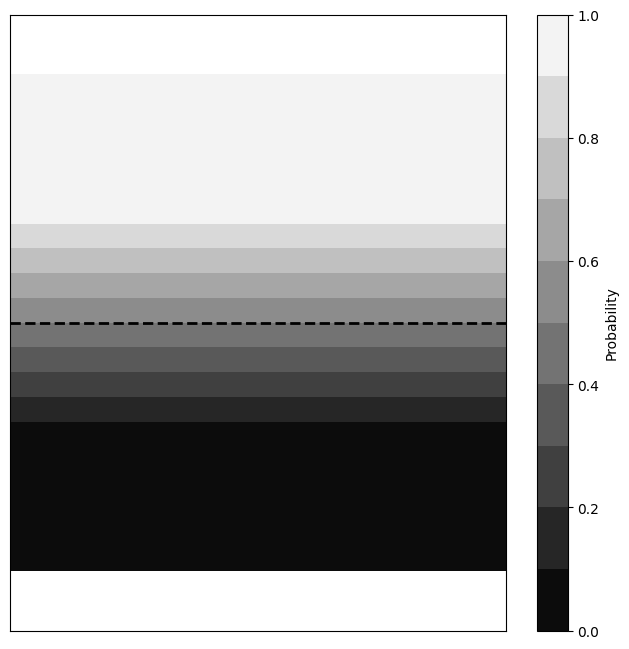

In [41]:
# Formulae - a horizontal line, at 0.
# With intensity 1 above the line, then dropping off smoothly to 0 below the line, with the line as a fuzzy boundary over a distance of 8 units.
# The line spans about 20 units.
x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)
# Use y2 to create a vertical transition along y, so Z is 1 above y=0, linearly decreases to 0 at y=-5, and 0 below
Z_profile = np.piecewise(
    y,
    [y >= 5, np.logical_and(y < 5, y > -5), y <= -5],
    [lambda y: 1, lambda y: (y + 5) / 10, lambda y: 0]
)
Z = np.tile(Z_profile, (X.shape[1], 1)).T


plt.figure(figsize=(8, 8))
plt.contourf(X, Y, Z, levels=10, cmap='grey')

# Add a horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='dashed', linewidth=2)

plt.colorbar(label='Probability')
plt.axis('equal')
# Hide the axis values
plt.xticks([])
plt.yticks([])
plt.show()
